In [16]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def initialize_centroids(X, K):
    centroids_idx = np.random.choice(len(X), K, replace=False)
    centroids = X[centroids_idx]
    return centroids

In [18]:
def assign_labels(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels

In [19]:
def update_centroids(X, labels, K):
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        if np.sum(labels == k) > 0:
            centroids[k] = np.mean(X[labels == k], axis=0)
        else:
            # If no points are assigned to cluster k, keep the centroid unchanged
            centroids[k] = X[np.random.choice(len(X))]  # Initialize with a random point
    return centroids

In [20]:
def calculate_sse(X, centroids, labels):
    sse = np.sum((X - centroids[labels]) ** 2)
    return sse

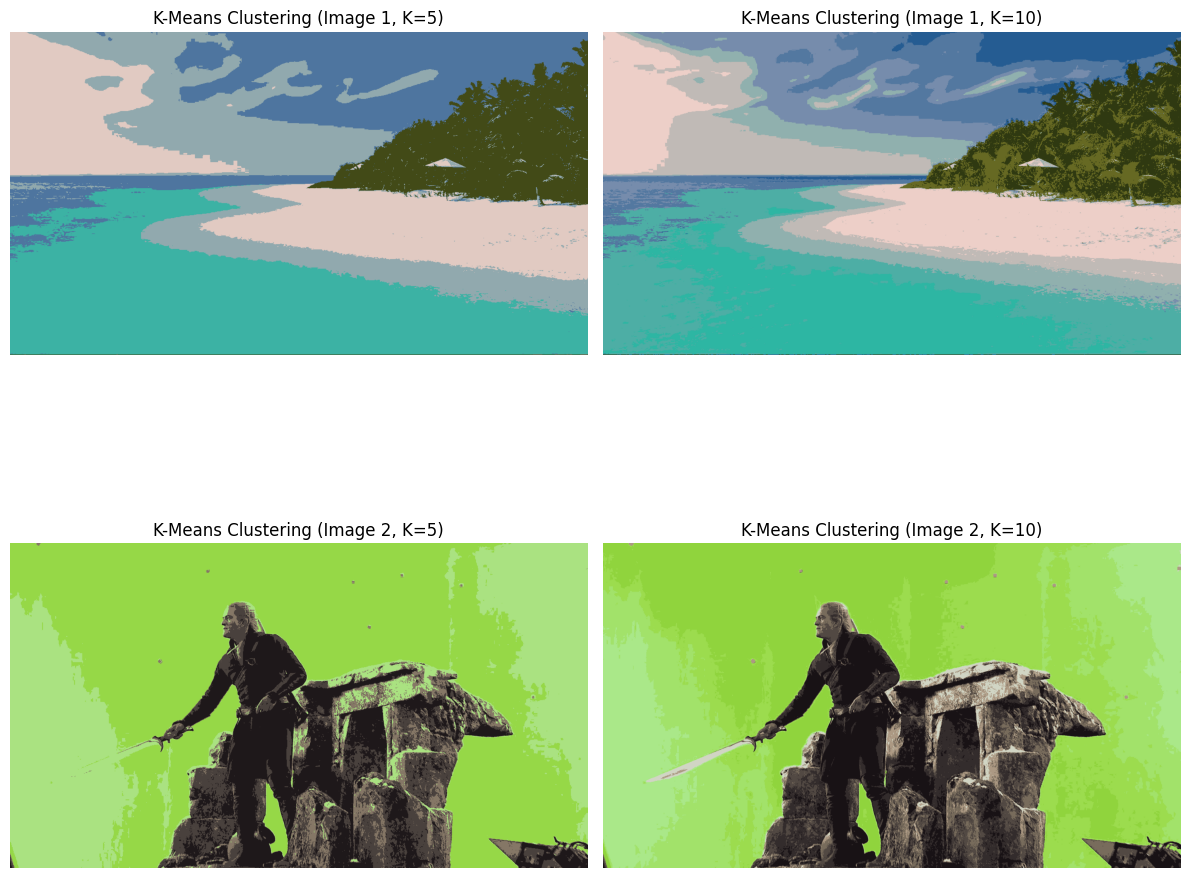

In [22]:
def kmeans_image(image_path, K, max_iters=100, n_runs=10):
    # Load image and convert to RGB array
    image = Image.open(image_path)
    image_data = np.array(image)
    h, w, _ = image_data.shape

    # Reshape image data to 2D array of pixels
    X = image_data.reshape((h * w, 3))

    # Apply K-Means clustering
    best_labels = None
    best_centers = None
    best_error = np.inf

    for _ in range(n_runs):
        # Initialize centroids randomly
        centroids = initialize_centroids(X, K)

        for _ in range(max_iters):
            # Assign labels based on closest centroid
            labels = assign_labels(X, centroids)

            # Update centroids based on mean of points in each cluster
            new_centroids = update_centroids(X, labels, K)

            # Check for convergence
            if np.all(centroids == new_centroids):
                break

            centroids = new_centroids

        # Calculate sum of squares error
        error = calculate_sse(X, centroids, labels)

        # Keep track of the best clustering solution
        if error < best_error:
            best_error = error
            best_labels = labels
            best_centers = centroids

    # Reshape labels to original image dimensions
    clustered_image = best_centers[best_labels].reshape((h, w, 3)).astype(np.uint8)

    return clustered_image

# Example usage for Kmean_img1.jpg and Kmean_img2.jpg with different K values
image1_path = r"/content/drive/MyDrive/CV_Programming_1/Part_2/B/Kmean_img1.jpg"
image2_path = r"/content/drive/MyDrive/CV_Programming_1/Part_2/B/Kmean_img2.jpg"

# Applying K-Means with K=5 to image1
clustered_image_1_5 = kmeans_image(image1_path, 5)

# Applying K-Means with K=10 to image1
clustered_image_1_10 = kmeans_image(image1_path, 10)

# Applying K-Means with K=5 to image2
clustered_image_2_5 = kmeans_image(image2_path, 5)

# Applying K-Means with K=10 to image2
clustered_image_2_10 = kmeans_image(image2_path, 10)

# Plotting the clustered images
plt.figure(figsize=(12, 12))

# Plotting for image1 with K=5
plt.subplot(2, 2, 1)
plt.imshow(clustered_image_1_5)
plt.title('K-Means Clustering (Image 1, K=5)')
plt.axis('off')

# Plotting for image1 with K=10
plt.subplot(2, 2, 2)
plt.imshow(clustered_image_1_10)
plt.title('K-Means Clustering (Image 1, K=10)')
plt.axis('off')

# Plotting for image2 with K=5
plt.subplot(2, 2, 3)
plt.imshow(clustered_image_2_5)
plt.title('K-Means Clustering (Image 2, K=5)')
plt.axis('off')

# Plotting for image2 with K=10
plt.subplot(2, 2, 4)
plt.imshow(clustered_image_2_10)
plt.title('K-Means Clustering (Image 2, K=10)')
plt.axis('off')

plt.tight_layout()
plt.show()
